# Policy Retention Prediction

**Author:** Aman Bohra · Senior Analytics & BI Professional
**Portfolio:** https://amandbohra.github.io/portfolio/

A classic decision-support model: predict which policyholders are likely **not to renew**, so retention
effort goes where it matters. Built on a **synthetic** P&C policy dataset with logistic regression —
chosen because it's interpretable, which is what makes a model usable for the business.

> ⚠️ Synthetic data for demonstration only — no real or confidential client data.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25})
rng = np.random.default_rng(11)


## 1. Synthetic policyholder dataset
Features with plausible, planted relationships to renewal (e.g. more prior claims and rising premium
lower the odds of renewal; longer tenure raises them).

In [2]:
N = 4000
tenure = rng.integers(1, 12, N)                       # years with insurer
premium = rng.normal(1200, 350, N).clip(300)          # annual premium
premium_hike = rng.normal(0.06, 0.05, N)              # YoY change
claims = rng.poisson(0.6, N)                           # prior claims
age = rng.integers(21, 75, N)
digital = rng.integers(0, 2, N)                        # engaged on digital channel

# latent renewal propensity
z = (0.9 + 0.18*tenure - 2.6*premium_hike - 0.35*claims
     + 0.008*(age-45) + 0.25*digital - 0.0002*(premium-1200))
p = 1/(1+np.exp(-z))
renewed = (rng.random(N) < p).astype(int)

df = pd.DataFrame({"tenure":tenure,"premium":premium.round(0),"premium_hike":premium_hike.round(3),
                   "prior_claims":claims,"age":age,"digital":digital,"renewed":renewed})
print("Renewal rate:", f"{df.renewed.mean():.1%}")
df.head()


Renewal rate: 83.2%


,tenure,premium,premium_hike,prior_claims,age,digital,renewed
0,2,2195.0,0.056,0,29,1,1
1,2,1419.0,0.162,1,38,1,1
2,9,1412.0,0.183,0,49,1,1
3,6,1257.0,0.047,1,43,1,1
4,7,1527.0,0.090,1,65,1,0


## 2. Train a logistic regression

In [3]:
X = df.drop(columns="renewed"); y = df["renewed"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=1, stratify=y)
sc = StandardScaler().fit(Xtr)
clf = LogisticRegression(max_iter=1000).fit(sc.transform(Xtr), ytr)

proba = clf.predict_proba(sc.transform(Xte))[:,1]
pred = (proba >= 0.5).astype(int)
auc = roc_auc_score(yte, proba)
print(f"ROC AUC: {auc:.3f}\n")
print(classification_report(yte, pred, target_names=["churn","renew"]))


ROC AUC: 0.647

              precision    recall  f1-score   support

       churn       0.75      0.02      0.03       168
       renew       0.83      1.00      0.91       832

    accuracy                           0.83      1000
   macro avg       0.79      0.51      0.47      1000
weighted avg       0.82      0.83      0.76      1000



## 3. ROC curve & what drives renewal

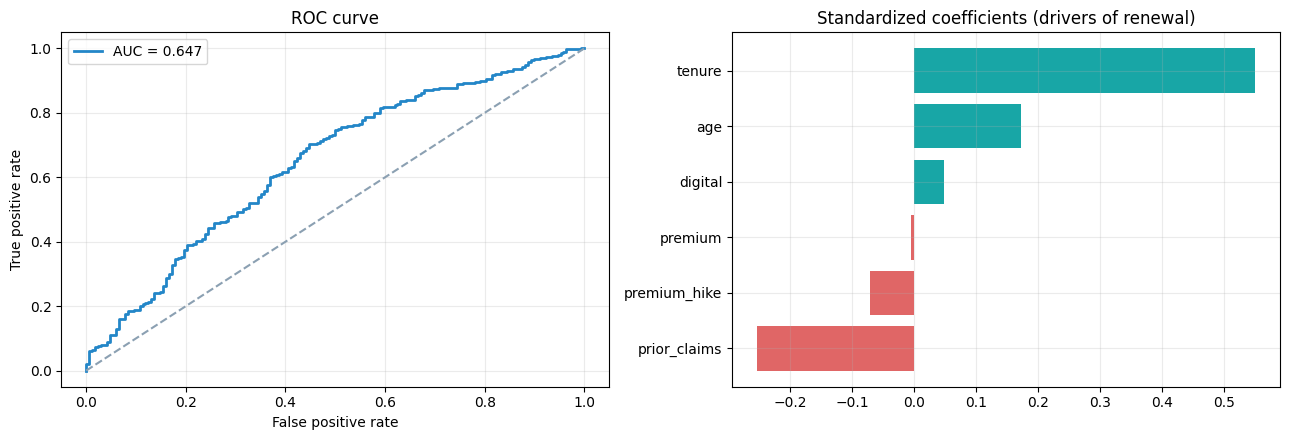

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
fpr, tpr, _ = roc_curve(yte, proba)
ax[0].plot(fpr, tpr, color="#2386c8", lw=2, label=f"AUC = {auc:.3f}")
ax[0].plot([0,1],[0,1],"--",color="#8ba0b2"); ax[0].set_title("ROC curve")
ax[0].set_xlabel("False positive rate"); ax[0].set_ylabel("True positive rate"); ax[0].legend()

coef = pd.Series(clf.coef_[0], index=X.columns).sort_values()
colors = ["#e06666" if c<0 else "#18a6a6" for c in coef.values]
ax[1].barh(coef.index, coef.values, color=colors)
ax[1].set_title("Standardized coefficients (drivers of renewal)")
plt.tight_layout(); plt.show()


## 4. Turn scores into action
Rank policyholders by predicted churn risk and focus retention on the riskiest, highest-value book.

In [5]:
scored = Xte.copy()
scored["churn_risk"] = 1 - proba
top = scored.sort_values("churn_risk", ascending=False).head(10)
top[["tenure","premium","premium_hike","prior_claims","churn_risk"]].round(3)


,tenure,premium,premium_hike,prior_claims,churn_risk
2999,1,591.0,0.058,4,0.621
1372,1,1464.0,0.140,4,0.557
1494,1,979.0,0.138,3,0.537
1884,1,790.0,0.111,4,0.537
1759,1,1429.0,0.116,2,0.459
1360,2,1154.0,0.037,3,0.458
1416,4,1035.0,0.062,4,0.446
3380,1,1181.0,0.055,2,0.440
483,3,1267.0,0.111,3,0.438
2595,1,1229.0,0.076,2,0.428


## 5. Business value
- **Targeted retention** — spend effort on the at-risk, high-value segment rather than everyone.
- **Interpretability** — the coefficients show *why* (premium hikes and prior claims push churn up), so
  the business trusts and acts on it.
- **Translation** — the model's real output isn't a probability; it's a prioritized call list.

*This is the "data science → decision" translation I focus on: a model in a notebook changes nothing;
a ranked action list changes retention.*

*— Aman Bohra*
